In [1]:
import pandas as pd
import networkx as nx
import numpy as np
from pyvis.network import Network
import matplotlib.pyplot as plt

/Users/emmet/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/emmet/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
# Import Prophage-prophage edgetable
start_row = 532197
end_row = 811844

pro_df = pd.read_csv(
    "data/Bipartite_BAC_PRO_genome_edgetable.csv",
    skiprows=range(1, start_row),
    nrows=end_row - start_row + 1
)

pro_df_unweighted = pro_df.copy()
pro_df_unweighted['Value'] = 1.0


In [3]:
# Import CRISPR-blast table
spacers_df = pd.read_csv("data/spacer_vs_provirus.raw.csv")
total_spacers = 9223
total_prophages = 3216
print("Without applying any BLAST filters:")
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
uniq_spacers = len(spacers_df['qseqid'].unique())
print(f"Num. unique CRISPR spacers with a prophage hit: {uniq_spacers}")
print(f"Num. unique spacers found with no prophage hit: {total_spacers - uniq_spacers}")
uniq_prophages = len(spacers_df['sseqid'].unique())
print(f"Num. unique prophages with a detected spacer hit: {uniq_prophages}")
print(f"Num. unique prophages found with no spacer hit: {total_prophages - uniq_prophages}")
print("\n")

# Get a df of only significant hits
e_threshold = 1e-5

# Mask dataframe to only get rows where evalue is less than the threshold
significant_df = spacers_df[(spacers_df['evalue'] < e_threshold)]

print("With BLAST filters:")
print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
# Info on proospacer hits
total_hits = len(spacers_df)
print(f"Total blast hits: {total_hits}")
print(f"Total significant hits (e < {e_threshold}): {(len(significant_df))}")

# Get dataframe from significant hits where the alignment length and query length is the same (full spacer was hit)
full_cov_df = spacers_df[(spacers_df['length'] == spacers_df['qlen'])]
print(f"Number of significant hits where spacer length == alignment length: {len(full_cov_df)}")
protospacer_df = full_cov_df[(full_cov_df['pident'] == 100)]
print(f"Number of hits where A) e-value < {e_threshold}, B) full spacer used, and C) pident = 100%: {len(protospacer_df)}")
(protospacer_df).head
#protospacer_df[(protospacer_df['bitscore'] < 60)]
#len(protospacer_df[(protospacer_df['bitscore'] < 57)])

#Distribution of spacers per genome (in those that have them!)


Without applying any BLAST filters:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Num. unique CRISPR spacers with a prophage hit: 5443
Num. unique spacers found with no prophage hit: 3780
Num. unique prophages with a detected spacer hit: 3215
Num. unique prophages found with no spacer hit: 1


With BLAST filters:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Total blast hits: 372495
Total significant hits (e < 1e-05): 181975
Number of significant hits where spacer length == alignment length: 147502
Number of hits where A) e-value < 1e-05, B) full spacer used, and C) pident = 100%: 82537


<bound method NDFrame.head of                                             qseqid  \
50           1007064.3|NC_015433_CRISPR_1_spacer_9   
51           1007064.3|NC_015433_CRISPR_1_spacer_9   
52          1007064.3|NC_015433_CRISPR_1_spacer_19   
53          1007064.3|NC_015433_CRISPR_1_spacer_19   
54          1007064.3|NC_015433_CRISPR_1_spacer_19   
...                                            ...   
372420       1380773.3|CP006645_CRISPR_1_spacer_10   
372421       1380773.3|CP006645_CRISPR_1_spacer_10   
372422       1380773.3|CP006645_CRISPR_1_spacer_10   
372468  286604.5|NZ_AAFA03000004_CRISPR_1_spacer_3   
372469  286604.5|NZ_AAFA03000004_CRISPR_1_spacer_3   

                                                   sseqid  pident  length  \
50        1214171.3_ALLK01000022_provirus-46062-83188.fna   100.0      30   
51      1307.5088_JAKTCI010000011_provirus-38647-70141...   100.0      30   
52        1307.5634_CP102148_provirus-1110120-1144990.fna   100.0      30   
53      1307.

In [4]:
# Okay working with pro_df and protospacer_df
proto_df = protospacer_df.filter(['qseqid', 'sseqid', 'evalue'], axis=1)
proto_df.columns = ('Source', 'Target', 'Value')

edgetable_df = pd.concat([pro_df, proto_df])
print(edgetable_df)
# Have prophage - prophage df
# Have spacer - prophage df
# Before editing edges to show self-targets, just make network

                                                 Source  \
0       1004951.3_CP002651_provirus-1291910-1341951.fna   
1       1004951.3_CP002651_provirus-1291910-1341951.fna   
2       1004951.3_CP002651_provirus-1291910-1341951.fna   
3       1004951.3_CP002651_provirus-1291910-1341951.fna   
4       1004951.3_CP002651_provirus-1291910-1341951.fna   
...                                                 ...   
372420            1380773.3|CP006645_CRISPR_1_spacer_10   
372421            1380773.3|CP006645_CRISPR_1_spacer_10   
372422            1380773.3|CP006645_CRISPR_1_spacer_10   
372468       286604.5|NZ_AAFA03000004_CRISPR_1_spacer_3   
372469       286604.5|NZ_AAFA03000004_CRISPR_1_spacer_3   

                                                   Target         Value  
0        1214153.3_ALLZ01000012_provirus-64795-114058.fna  1.000000e+00  
1         1307.1455_CZGR01000001_provirus-19554-48536.fna  4.942529e-01  
2       1307.1455_CZGR01000075_provirus-109988-129716.fna  4.534884e-

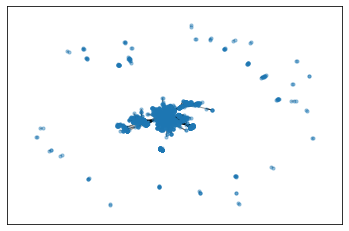

In [5]:
# Make the actual network
G = nx.from_pandas_edgelist(df=edgetable_df, source='Source', target='Target', edge_attr='Value')
# Set seed for spring layout positioning?
pos = nx.spring_layout(G, seed=67676767)

# Colour nodes
options = {"edgecolors": "tab:gray", "node_size": 10, "alpha": 0.4}
nx.draw_networkx_nodes(G, pos, nodelist=[])

nx.draw_networkx(G, with_labels=False, node_size=10, alpha=0.4)

In [6]:
# Wait what are the nodes called
all_nodes = list(G.nodes)

# Store only prophage nodes
prophage_nodes = [] 
spacer_nodes = []
why_is_there_anything_here_lol = []

for node in all_nodes:
    if "provirus" in node:
        prophage_nodes.append(node)
    elif "spacer" in node:
        spacer_nodes.append(node)
    else:
        why_is_there_anything_here_lol.append(node)
print(len(all_nodes))
print(len(prophage_nodes))
print(len(spacer_nodes))
print(len(why_is_there_anything_here_lol))

# See what the craic is with the edges to try and mask them
# Wait what are the nodes called
all_edges = list(G.edges)

# Store only prophage nodes
pro_pro_edges = [] 
pro_spacer_edges = []
why_is_there_anything_here_lol = []

#for edge in all_edges:
#    print(edge[0])

for edge in all_edges:
    if ("spacer" not in edge[0]) & ("spacer" not in edge[1]):
        pro_pro_edges.append(edge)
    elif ("spacer" in edge[0]) | ("spacer" in edge[1]):
        pro_spacer_edges.append(edge)
    else:
        why_is_there_anything_here_lol.append(edge)
print(f"Total number of edges: {len(all_edges)}")
print(f"Number of prophage-prophage edges: {len(pro_pro_edges)}")
print(f"Number of edges that doesn't fit these criteria??: {len(why_is_there_anything_here_lol)}")
print(f"Number of prophage-spacer edges: {len(pro_spacer_edges)}")

5884
3158
2726
0
Total number of edges: 361835
Number of prophage-prophage edges: 279648
Number of edges that doesn't fit these criteria??: 0
Number of prophage-spacer edges: 82187


In [7]:
# Use the REAL Louvain communities from the Netpass pipeline (min-weight 44,
# the elbow threshold for this exact edge table) instead of relying on
# spring_layout to magically reveal structure on its own.
community_df = pd.read_csv("data/genome_community_mapping_44_PRO.csv")
node_to_community = dict(zip(community_df["Genome_ID"], community_df["Community"]))

from collections import defaultdict
community_members = defaultdict(list)
for node in prophage_nodes:
    comm = node_to_community.get(node)
    if comm is not None:
        community_members[comm].append(node)

# Largest communities first, so they claim more room when packing
ordered_communities = sorted(community_members.values(), key=len, reverse=True)
print(f"Number of communities represented in the network: {len(ordered_communities)}")
print(f"Largest community size: {len(ordered_communities[0])}")
print(f"Number of singleton communities: {sum(1 for c in ordered_communities if len(c) == 1)}")

# Pack communities into non-overlapping regions. spring_layout on a cycle graph
# doesn't know how big each community is, so the giant community ends up
# overlapping the small ones. Instead, greedily place a circle (radius ~ local_scale)
# per community along an expanding spiral, only accepting a position once it
# doesn't intersect any circle already placed -- this guarantees no overlap.
def pack_circles(items, spacing_factor=1.15):
    """items: list of (key, radius), largest first. Returns {key: (x, y)}."""
    placed = []  # (x, y, radius)
    positions = {}
    for key, r in items:
        if not placed:
            positions[key] = (0.0, 0.0)
            placed.append((0.0, 0.0, r))
            continue

        dist = r
        found = False
        while not found:
            steps = max(16, int(dist * 2))
            for i in range(steps):
                theta = 2 * np.pi * i / steps
                x, y = dist * np.cos(theta), dist * np.sin(theta)
                if all(
                    np.hypot(x - px, y - py) >= (r + pr) * spacing_factor
                    for px, py, pr in placed
                ):
                    positions[key] = (x, y)
                    placed.append((x, y, r))
                    found = True
                    break
            dist += max(1.0, r * 0.25)
    return positions

community_radii = [1 + np.sqrt(len(comm)) for comm in ordered_communities]
pack_items = [(i, community_radii[i]) for i in range(len(ordered_communities))]
centers_by_index = pack_circles(pack_items)
centers = [centers_by_index[i] for i in range(len(ordered_communities))]

pos = {}
for center, comm, radius in zip(centers, ordered_communities, community_radii):
    if len(comm) == 1:
        pos[comm[0]] = center
        continue
    # Use G (not G_layout) for the weighted subgraph -- G_layout was built with
    # add_edges_from() and never carried the Jaccard "Value" weight attribute
    subg = G.subgraph(comm)
    pos.update(
        nx.spring_layout(subg, weight="Value", center=center, scale=radius, seed=1430)
    )

# Fallback for any prophage with no community assignment in the mapping table
for prophage in prophage_nodes:
    if prophage not in pos:
        pos[prophage] = (np.random.normal(), np.random.normal())

# Colour the largest communities distinctly; lump smaller/singleton communities as gray
N_HIGHLIGHT = 15
cmap = plt.get_cmap("tab20")
community_colors = {}
for i, comm in enumerate(ordered_communities[:N_HIGHLIGHT]):
    color = cmap(i % 20)
    for node in comm:
        community_colors[node] = color
for comm in ordered_communities[N_HIGHLIGHT:]:
    for node in comm:
        community_colors[node] = "lightgray"

prophage_node_colors = [community_colors.get(n, "lightgray") for n in prophage_nodes]

Number of communities represented in the network: 558
Largest community size: 713
Number of singleton communities: 255


Self-targeting spacer-prophage edges: 18
Other (cross-genome) spacer-prophage edges: 82169


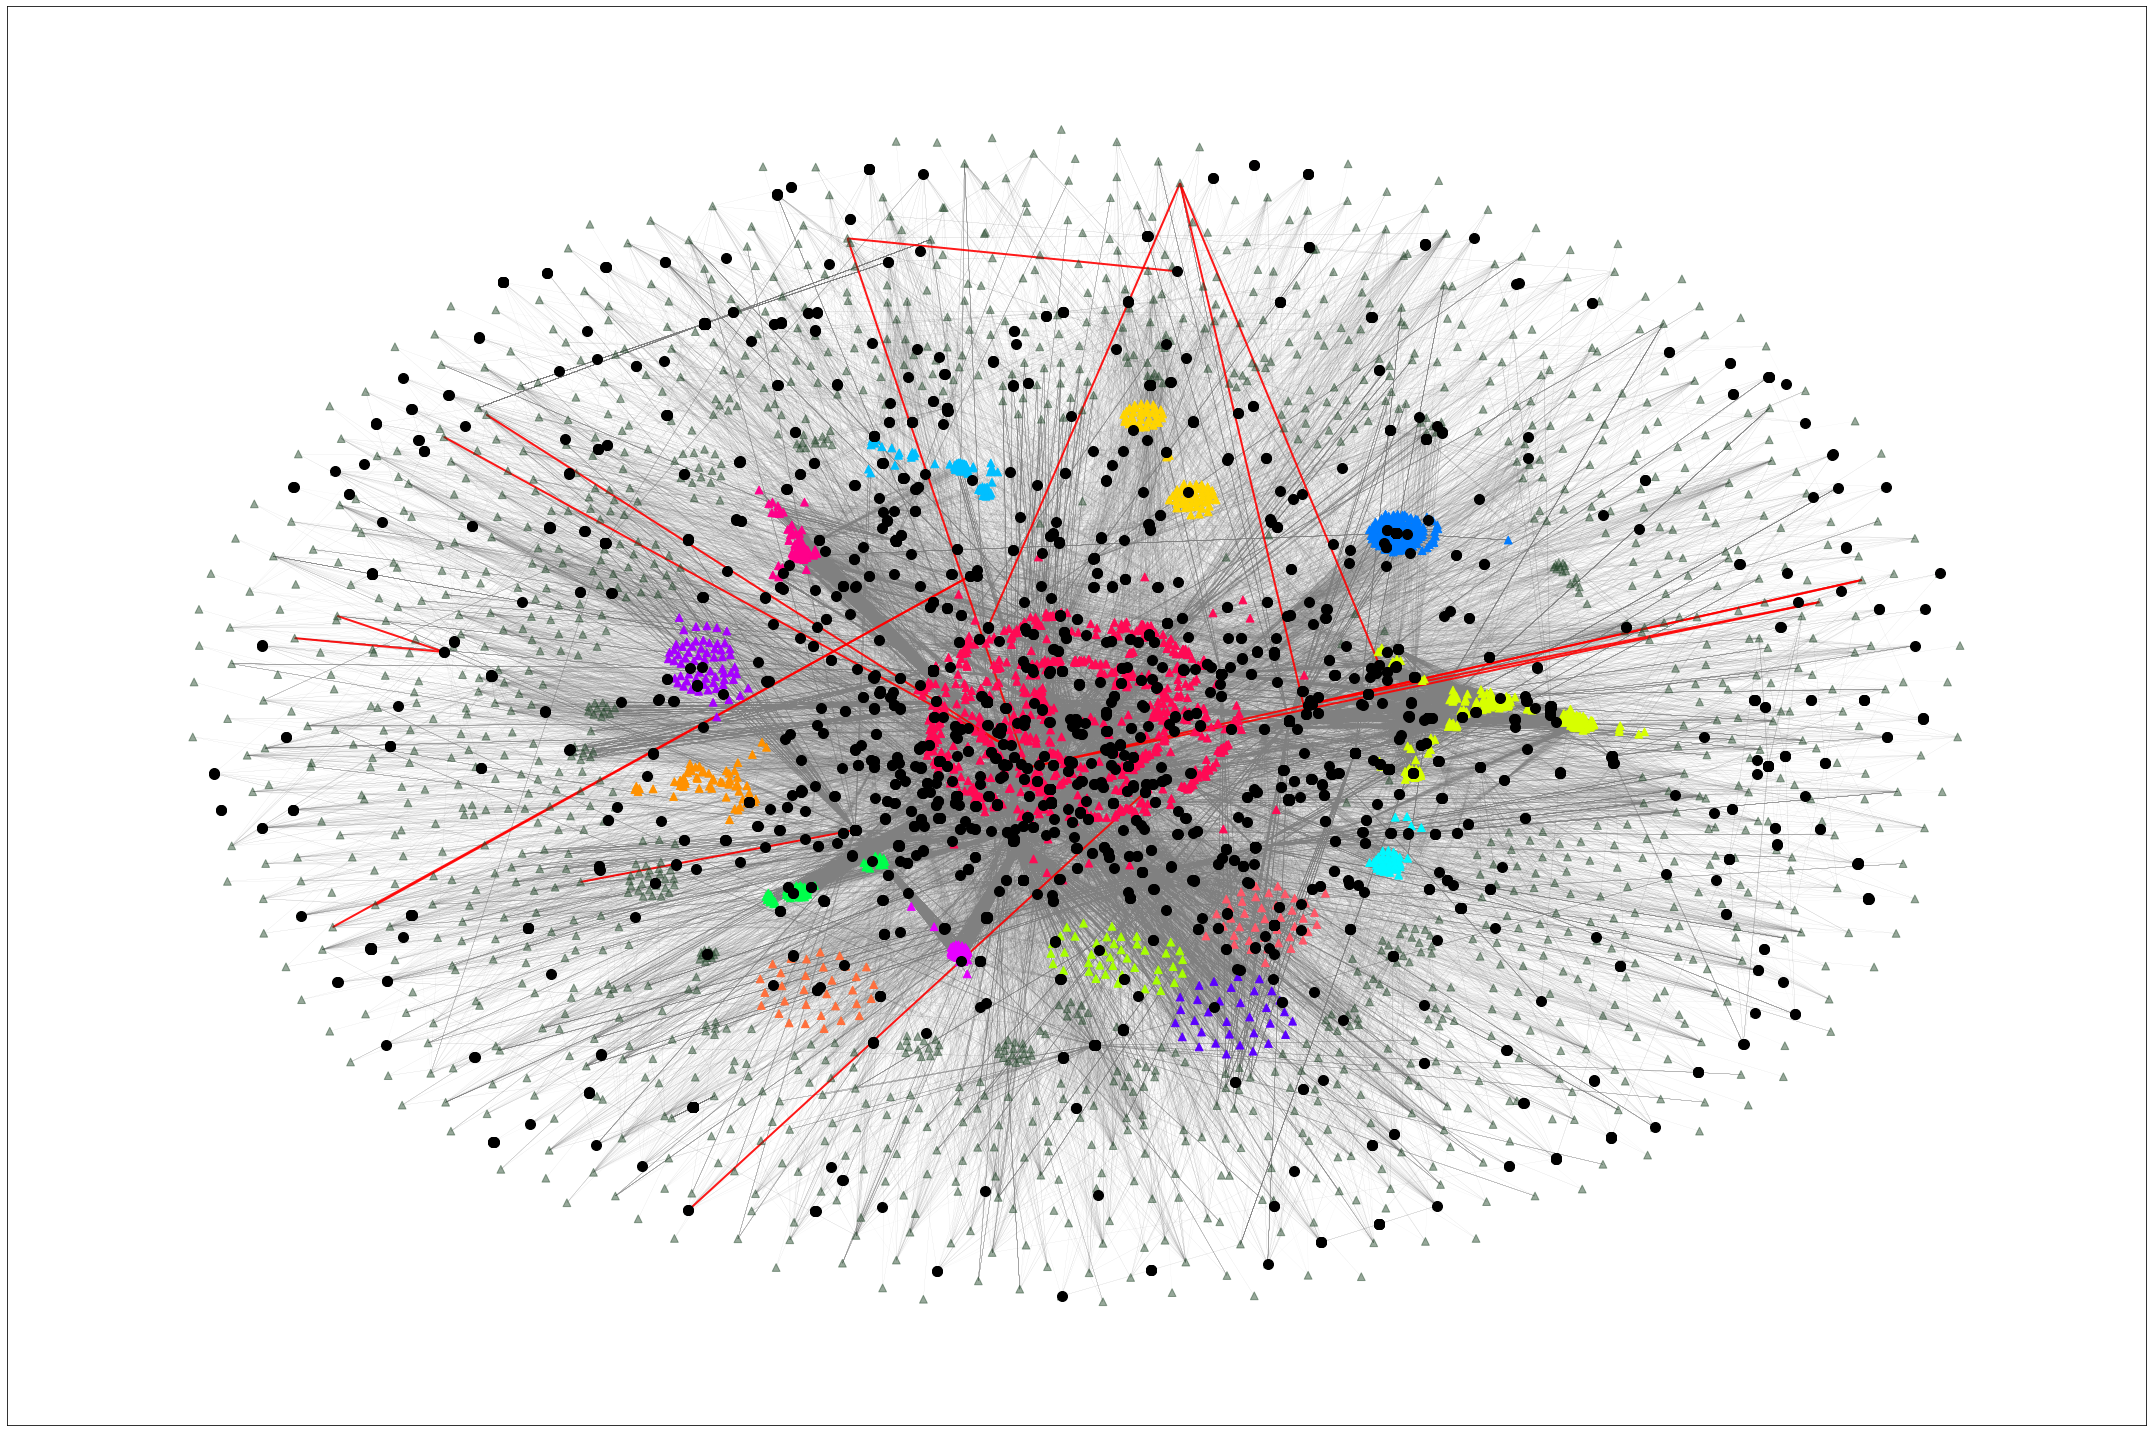

In [8]:
# Full graph
G = nx.from_pandas_edgelist(
    edgetable_df,
    source="Source",
    target="Target",
    edge_attr="Value"
)

# pos and prophage_node_colors were built in the previous cell from the real
# Louvain communities (Netpass, min-weight 44) -- prophage-prophage structure
# alone determines layout, communities determine grouping/colour.

# A spacer self-targets (protospacer hit within its own genome) when its genome
# ID matches the genome ID of the prophage it hits. Spacer IDs look like
# "1005042.3|CP002641_CRISPR_1_spacer_2" (genome ID before "|"); prophage IDs
# look like "1307.991_FIOP01000002_provirus-26606-66722.fna" (genome ID before "_").
def genome_id_of(node):
    if "|" in node:
        return node.split("|")[0]
    return node.split("_")[0]

self_hit_edges = []
other_spacer_edges = []
for u, v in pro_spacer_edges:
    spacer_node, prophage_node = (u, v) if "spacer" in u else (v, u)
    if genome_id_of(spacer_node) == genome_id_of(prophage_node):
        self_hit_edges.append((u, v))
    else:
        other_spacer_edges.append((u, v))

print(f"Self-targeting spacer-prophage edges: {len(self_hit_edges)}")
print(f"Other (cross-genome) spacer-prophage edges: {len(other_spacer_edges)}")

# Give every spacer a position
for spacer in spacer_nodes:

    neighbours = list(G.neighbors(spacer))

    # Find neighbours that already have coordinates
    positioned_neighbours = [n for n in neighbours if n in pos]

    if len(positioned_neighbours) > 0:

        # Place spacer near the mean position of connected prophages
        x, y = np.mean(
            [pos[n] for n in positioned_neighbours],
            axis=0
        )

        pos[spacer] = (
            x + np.random.normal(scale=0.02),
            y + np.random.normal(scale=0.02)
        )

    else:
        # Fallback position if no positioned neighbour exists
        pos[spacer] = (
            np.random.normal(),
            np.random.normal()
        )

plt.figure(figsize=(30, 20))

# Prophage-prophage edges determine structure
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=pro_pro_edges,
    alpha=0,
    width=0.2
)

# Cross-genome spacer-prophage edges are only displayed (cosmetic)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=other_spacer_edges,
    edge_color="gray",
    alpha=0.3,
    width=0.1
)

# Self-targeting spacer-prophage edges, drawn last so they stay visible
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=self_hit_edges,
    edge_color="red",
    alpha=0.9,
    width=2
)

pro_pal = ["#FF0A54","#D7FF00","#007BFF","#FFD500","#00BFFF","#FF008A","#A600FF",
           "#FF9100","#00FF4B","#E600FF","#A7FF00","#FF5768","#00F8FF","#5A00FF","#FF6F3C"]

pro_sizes = community_df["Community"].value_counts()
pro_top_ids = pro_sizes.sort_values(ascending=False).head(N_HIGHLIGHT).index.tolist()
pro_color_map = dict(zip(pro_top_ids, pro_pal))

prophage_node_colors = [
    pro_color_map.get(node_to_community.get(n), "#21452877") for n in prophage_nodes
]

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=prophage_nodes,
    node_color=prophage_node_colors,
    node_size=60,
    node_shape="^"
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=spacer_nodes,
    node_color="black",
    node_shape="o",
    node_size=100
)

plt.axis("on")
plt.tight_layout()
plt.savefig("Draft3_Bipartite_CRISPR_prophage.png", dpi=300)
plt.show()

In [9]:
# ============================================================================
# Results 5.2.4 -- who targets whom? Self-contained CRISPR-targeting analysis.
#   - bacterial-community spacer inventories (immunity hub vs defenceless sink)
#   - self-community immunity (spacers targeting a resident prophage community)
#   - most-targeted prophage communities (and their lineage structure)
# ============================================================================
import collections

# --- mappings ---
bac = pd.read_csv('data/genome_community_mapping_49_BAC.csv'); bac['gid'] = bac['Genome_ID'].str.replace('.fna', '', regex=False)
g2bac = dict(zip(bac['gid'], bac['Community']))                      # genome -> bacterial community
proC = pd.read_csv('data/genome_community_mapping_44_PRO.csv'); p2com = dict(zip(proC['Genome_ID'], proC['Community']))  # provirus -> prophage community
links = pd.read_csv('data/community_questions/q3_genome_procom_links.csv')  # bac_genome, bac_comm, pro_comm
q3 = pd.read_csv('data/community_questions/q3_baccomm_procoms.csv')

# --- filtered protospacer hits (Source=spacer, Target=prophage) ---
h = pd.read_csv('data/Protospacer_hits.csv')
h['sp_gen'] = h['Source'].str.split('|').str[0]                      # spacer's genome
h['pp_gen'] = h['Target'].str.split('_').str[0]                     # prophage's genome
h['sp_bac'] = h['sp_gen'].map(g2bac)
h['pp_bac'] = h['pp_gen'].map(g2bac)
h['pp_com'] = h['Target'].map(p2com)                                # targeted prophage community

# --- spacers per bacterial community (from all_spacers.fasta) ---
spac = collections.Counter()
for line in open('data/all_spacers.fasta'):
    if line.startswith('>'):
        spac[line[1:].split('|')[0]] += 1
percom = collections.Counter()
for gid, n in spac.items():
    if gid in g2bac:
        percom[g2bac[gid]] += n
print('Spacers per bacterial community (top 5):', percom.most_common(5))
print(f'  BAC_com_3 (immunity hub): {percom.get(3,0)} spacers, {(h.sp_bac==3).sum()} outgoing hits')
print(f'  BAC_com_5 (permissive sink): {percom.get(5,0)} spacers, prophages targeted by {(h.pp_bac==5).sum()} incoming hits')

# --- permissiveness: prophage communities per member genome ---
print('\nMost permissive communities (pro-coms/member, >=20 genomes):')
print(q3[q3.n_genomes >= 20].sort_values('procomm_per_member', ascending=False)
      [['bac_comm', 'n_genomes', 'n_procomm_connections', 'procomm_per_member']].head(5).to_string(index=False))

# --- self-community immunity (vectorised set membership) ---
host_gc = set((g.replace('.fna', ''), int(pc.replace('PRO_com_', '')))
              for g, pc in zip(links.bac_genome, links.pro_comm) if pd.notna(pc))          # (genome, pro-com) it hosts
host_bc = set((bc, int(pc.replace('PRO_com_', '')))
              for bc, pc in zip(links.bac_comm, links.pro_comm) if pd.notna(pc))           # (bac-com, pro-com) it hosts
gsel = sum((g, int(c)) in host_gc for g, c in zip(h.sp_gen, h.pp_com) if pd.notna(c))
csel = sum((f'BAC_com_{int(b)}', int(c)) in host_bc for b, c in zip(h.sp_bac, h.pp_com) if pd.notna(c) and pd.notna(b))
print(f'\nSelf-community immunity (of {len(h)} hits): {gsel} spacer-host genome also hosts target pro-com; '
      f'{csel} ({100*csel/len(h):.0f}%) spacer-host COMMUNITY also hosts it')

# --- most-targeted prophage communities + their lineage structure ---
print('\nMost-targeted prophage communities (by no. distinct spacers):')
mt = h.groupby('pp_com')['Source'].nunique().sort_values(ascending=False).head(5)
for com, nsp in mt.items():
    hosts = links[links.pro_comm == f'PRO_com_{int(com)}'].bac_comm.value_counts().head(2).to_dict()
    frm = h[h.pp_com == com].sp_bac.value_counts().head(2)
    frm = {f'BAC_com_{int(k)}': int(v) for k, v in frm.items()}
    print(f'  PRO_com_{int(com)}: {nsp} spacers, {(h.pp_com==com).sum()} hits | hosted in {hosts} | targeted by {frm}')


Spacers per bacterial community (top 5): [(3, 2847), (51, 371), (95, 319), (25, 286), (97, 280)]
  BAC_com_3 (immunity hub): 2847 spacers, 32448 outgoing hits
  BAC_com_5 (permissive sink): 0 spacers, prophages targeted by 6341 incoming hits

Most permissive communities (pro-coms/member, >=20 genomes):
  bac_comm  n_genomes  n_procomm_connections  procomm_per_member
BAC_com_41         30                     19            0.633333
BAC_com_34         42                     24            0.571429
 BAC_com_5         72                     39            0.541667
 BAC_com_3        429                     49            0.114219
 BAC_com_2        963                     83            0.086189

Self-community immunity (of 82537 hits): 3466 spacer-host genome also hosts target pro-com; 21004 (25%) spacer-host COMMUNITY also hosts it

Most-targeted prophage communities (by no. distinct spacers):
  PRO_com_5: 463 spacers, 11611 hits | hosted in {'BAC_com_3': 171, 'BAC_com_2': 24} | targeted by {'B